data

In [6]:
# data
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

!cp -r "/content/drive/MyDrive/medical-mnist" "/content/"
DATA_DIR = "/content/medical-mnist"

IMG_SIZE = 64
BATCH_SIZE = 32
LATENT_DIM = 128
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x

train_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    validation_split=0.2,
    subset="training",
    seed=42,
    batch_size=None,
    label_mode="int"
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    validation_split=0.2,
    subset="validation",
    seed=42,
    batch_size=None,
    label_mode="int"
)

class_names = train_raw.class_names
print("Classes:", class_names)

# help
def make_ds(ds, training=True):
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

def add_noise(x):
    noise = tf.random.normal(tf.shape(x), stddev=0.1)
    return tf.clip_by_value(x + noise, 0., 1.)

def preprocess_vae(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x

def filter_by_class(ds, class_id):
    return ds.filter(lambda x, y: tf.equal(y, class_id))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 58954 files belonging to 6 classes.
Using 47164 files for training.
Found 58954 files belonging to 6 classes.
Using 11790 files for validation.
Classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


models

In [7]:
#AE
def build_ae():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = layers.Conv2D(32, 3, 2, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(64, 3, 2, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, 2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)

    z = layers.Dense(LATENT_DIM)(x)

    x = layers.Dense(8*8*128, activation="relu")(z)
    x = layers.Reshape((8,8,128))(x)

    x = layers.Conv2DTranspose(128, 3, 2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, 2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, 2, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model


In [8]:

# VAE
class VAE(keras.Model):
    def __init__(self, beta=0.1):
        super().__init__()
        self.beta = beta

        self.encoder = keras.Sequential([
            layers.Conv2D(32,3,2,padding="same",activation="relu"),
            layers.Conv2D(64,3,2,padding="same",activation="relu"),
            layers.Conv2D(128,3,2,padding="same",activation="relu"),
            layers.Flatten()
        ])

        self.mu = layers.Dense(LATENT_DIM)
        self.logvar = layers.Dense(LATENT_DIM)

        self.decoder = keras.Sequential([
            layers.Dense(8*8*128,activation="relu"),
            layers.Reshape((8,8,128)),
            layers.Conv2DTranspose(128,3,2,padding="same",activation="relu"),
            layers.Conv2DTranspose(64,3,2,padding="same",activation="relu"),
            layers.Conv2DTranspose(32,3,2,padding="same",activation="relu"),
            layers.Conv2D(1,3,padding="same",activation="sigmoid")
        ])

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker,
                self.recon_loss_tracker,
                self.kl_loss_tracker]

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data

        with tf.GradientTape() as tape:
            h = self.encoder(x)
            mu = self.mu(h)
            logvar = self.logvar(h)

            eps = tf.random.normal(shape=tf.shape(mu))
            z = mu + tf.exp(0.5 * logvar) * eps

            x_hat = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(x, x_hat),
                    axis=(1,2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + logvar - tf.square(mu) - tf.exp(logvar),
                    axis=1
                )
            )

            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data

        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)

        eps = tf.random.normal(shape=tf.shape(mu))
        z = mu + tf.exp(0.5 * logvar) * eps

        x_hat = self.decoder(z)

        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(x, x_hat),
                axis=(1,2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + logvar - tf.square(mu) - tf.exp(logvar),
                axis=1
            )
        )

        total_loss = recon_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    def call(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)

        eps = tf.random.normal(shape=tf.shape(mu))
        z = mu + tf.exp(0.5 * logvar) * eps

        return self.decoder(z)


training

In [10]:
# main for all classes
saved_models = {}
for class_id, class_name in enumerate(class_names):

    print(f"\n {class_name}")

    train_class = filter_by_class(train_raw, class_id).take(600)
    val_class = filter_by_class(val_raw, class_id).take(200)

    train_ds = make_ds(train_class)
    val_ds = make_ds(val_class, training=False)

    # AE
    ae = build_ae()
    ae_hist = ae.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

    #DAE
    train_denoise = train_ds.map(lambda x,y: (add_noise(x), x))
    dae = build_ae()
    dae_hist = dae.fit(train_denoise, validation_data=val_ds, epochs=EPOCHS)

    # VAE
    train_vae = train_class.map(preprocess_vae).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    val_vae = val_class.map(preprocess_vae).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    vae = VAE()
    vae.compile(optimizer="adam")
    vae_hist = vae.fit(train_vae, validation_data=val_vae, epochs=EPOCHS)
    saved_models[class_name] = {
      "ae": ae,
      "dae": dae,
      "vae": vae,
      "val_ds": val_ds,
      "train_vae": train_vae,
      "ae_hist": ae_hist,
      "dae_hist": dae_hist,
      "vae_hist": vae_hist
    }


 AbdomenCT
Epoch 1/15
     19/Unknown 15s 110ms/step - loss: 0.0133

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 354ms/step - loss: 0.0127 - val_loss: 0.0105
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - loss: 0.0091 - val_loss: 0.0082
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - loss: 0.0077 - val_loss: 0.0077
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - loss: 0.0073 - val_loss: 0.0069
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - loss: 0.0065 - val_loss: 0.0063
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 206ms/step - loss: 0.0057 - val_loss: 0.0055
Epoch 9/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - loss: 0.0053 - val_loss: 0.0054
Epoch 10/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - loss: 0.0050 - val_loss: 0.0052
Epoch 11/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - loss: 0.0048 - val_loss: 0.0050
Epoch 12/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/ste

utilities and visualizations

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


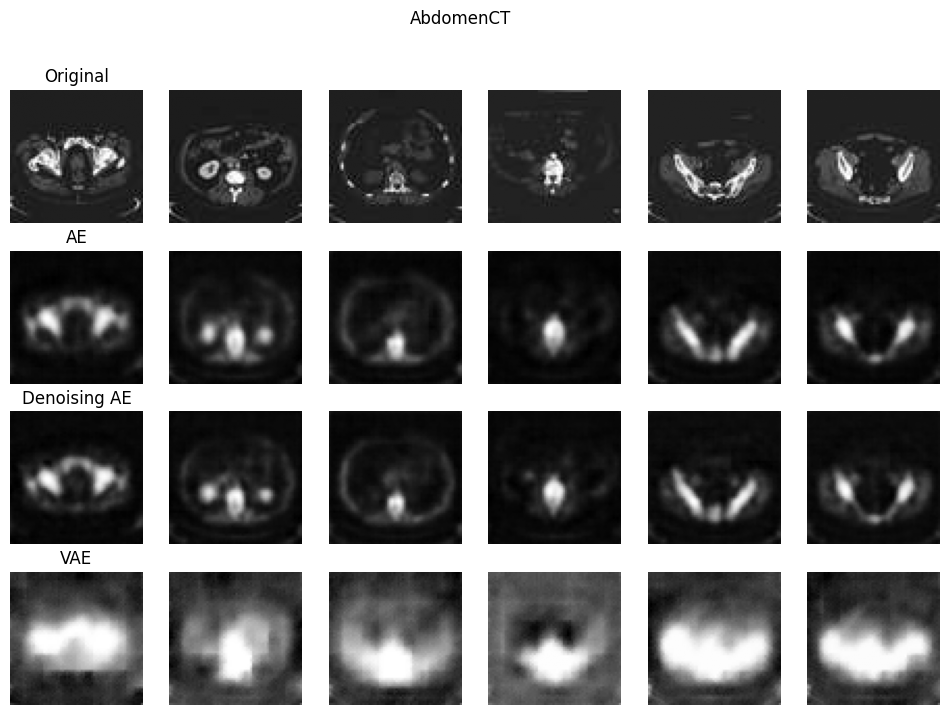

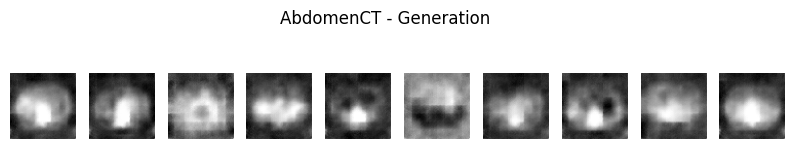

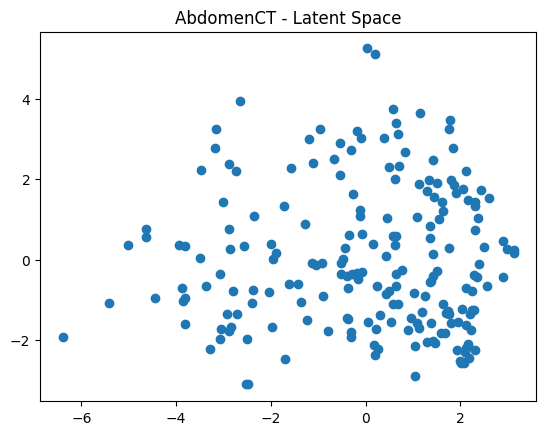

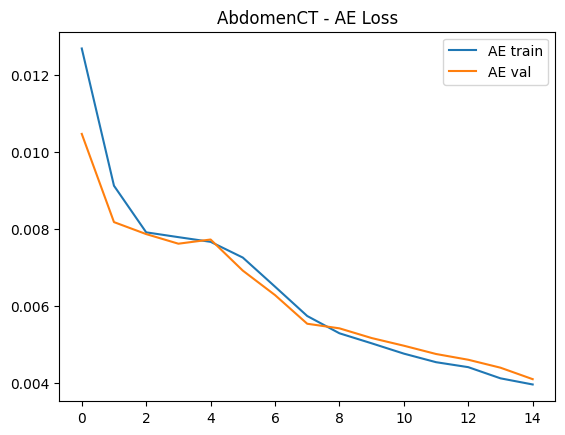

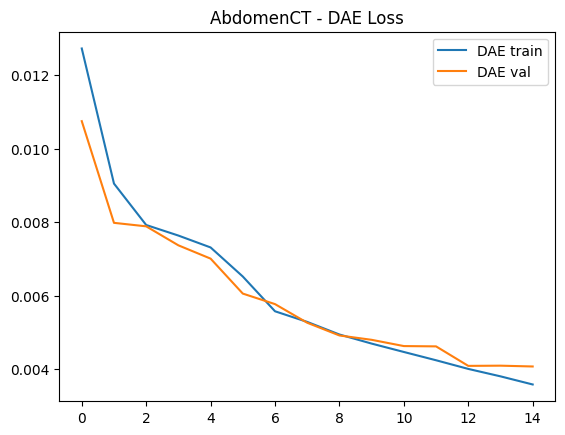

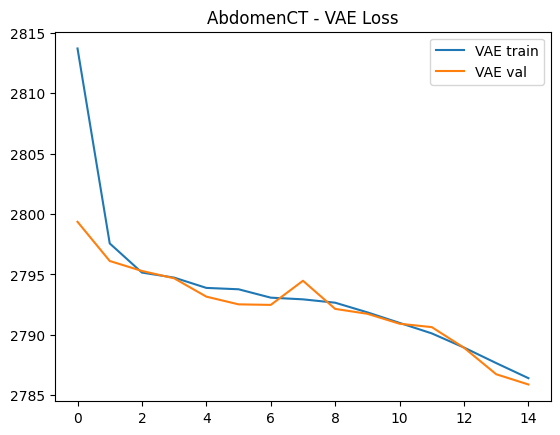

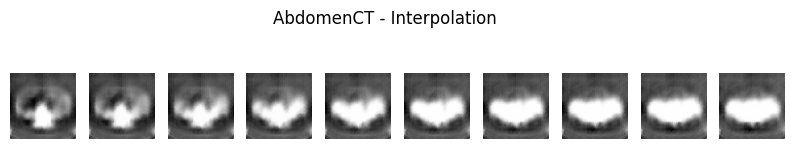

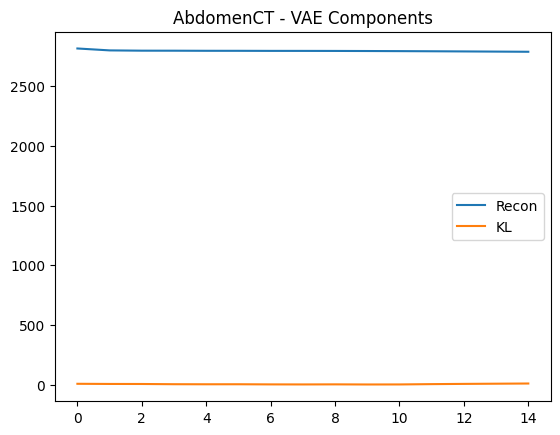

In [14]:
class_name = "AbdomenCT"

data = saved_models[class_name]

ae = data["ae"]
dae = data["dae"]
vae = data["vae"]
val_ds = data["val_ds"]
train_vae = data["train_vae"]
ae_hist = data["ae_hist"]
dae_hist = data["dae_hist"]
vae_hist = data["vae_hist"]

# reconstruction
x_batch,_ = next(iter(val_ds))

ae_pred = ae.predict(x_batch[:6])
dae_pred = dae.predict(x_batch[:6])
vae_pred = vae.predict(x_batch[:6])

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(4,6,i+1)
    plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # AE
    plt.subplot(4,6,i+7)
    img = ae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("AE")

    # DAE
    plt.subplot(4,6,i+13)
    img = dae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Denoising AE")

    # VAE
    plt.subplot(4,6,i+19)
    img = vae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE")

plt.suptitle(class_name)
plt.show()


# generation
z = tf.random.normal((10, LATENT_DIM))
gen = vae.decoder(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle(f"{class_name} - Generation")
plt.show()


# latent space
z_all = []
for x,_ in val_ds.take(10):
    mu = vae.mu(vae.encoder(x))
    z_all.append(mu.numpy())

z_all = np.concatenate(z_all)
z_2d = PCA(2).fit_transform(z_all)

plt.scatter(z_2d[:,0], z_2d[:,1])
plt.title(f"{class_name} - Latent Space")
plt.show()


# loss
plt.plot(ae_hist.history['loss'], label='AE train')
plt.plot(ae_hist.history['val_loss'], label='AE val')
plt.legend()
plt.title(f"{class_name} - AE Loss")
plt.show()

plt.plot(dae_hist.history['loss'], label='DAE train')
plt.plot(dae_hist.history['val_loss'], label='DAE val')
plt.legend()
plt.title(f"{class_name} - DAE Loss")
plt.show()

plt.plot(vae_hist.history['loss'], label='VAE train')
plt.plot(vae_hist.history['val_loss'], label='VAE val')
plt.legend()
plt.title(f"{class_name} - VAE Loss")
plt.show()


# interpolation
x,_ = next(iter(val_ds))

mu1 = vae.mu(vae.encoder(x[:1]))
mu2 = vae.mu(vae.encoder(x[1:2]))

plt.figure(figsize=(10,2))
for i,a in enumerate(np.linspace(0,1,10)):
    z = (1-a)*mu1 + a*mu2
    img = vae.decoder(z)

    plt.subplot(1,10,i+1)
    plt.imshow(img[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"{class_name} - Interpolation")
plt.show()


# VAE loss components
plt.plot(vae_hist.history['recon_loss'], label='Recon')
plt.plot(vae_hist.history['kl_loss'], label='KL')
plt.legend()
plt.title(f"{class_name} - VAE Components")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


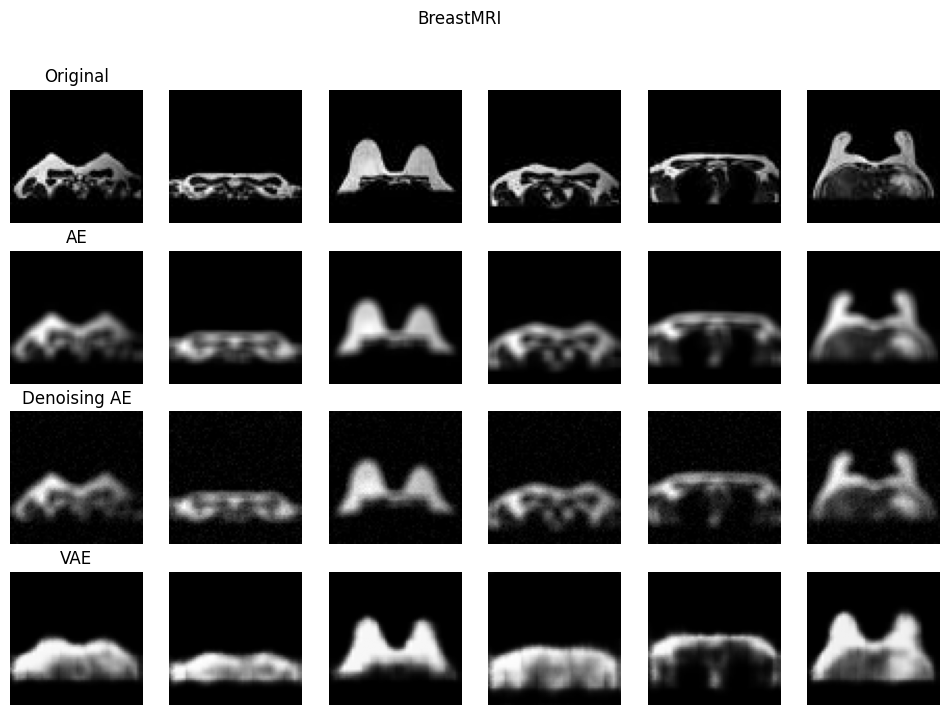

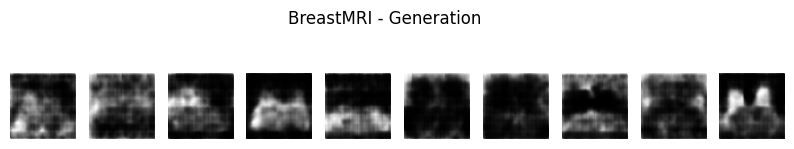

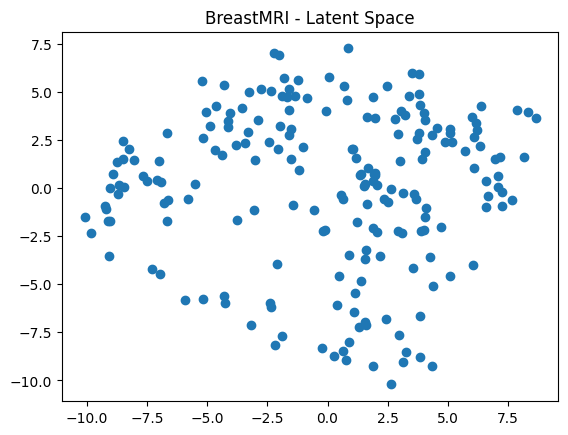

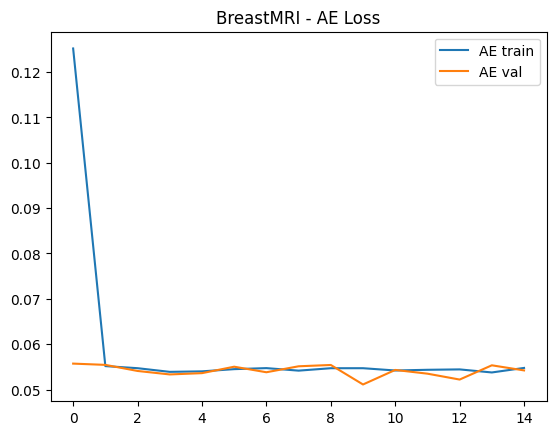

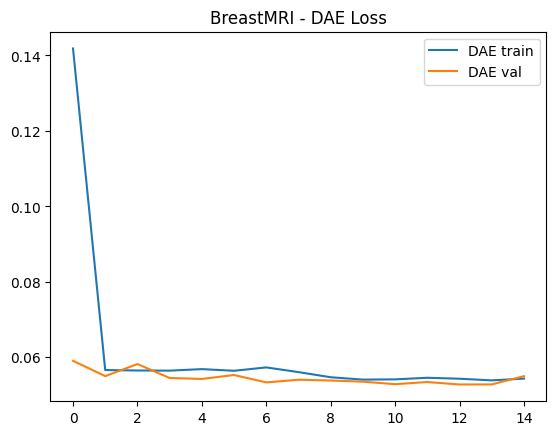

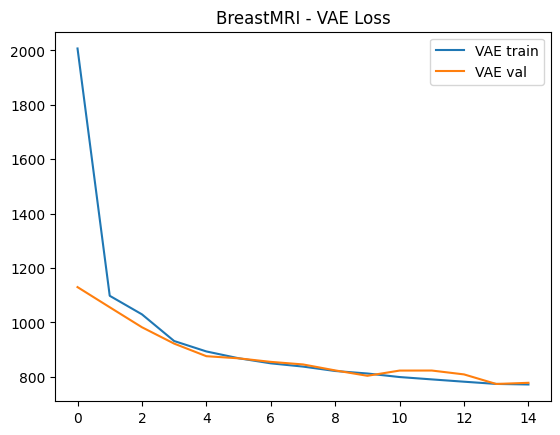

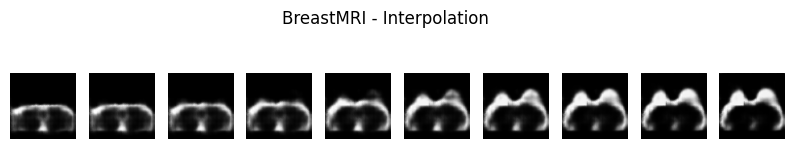

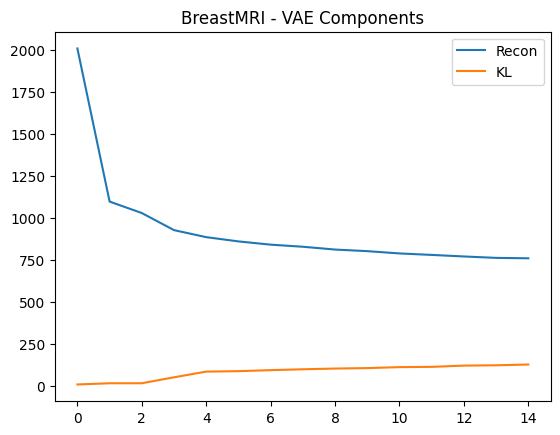

In [17]:
class_name = "BreastMRI"

data = saved_models[class_name]

ae = data["ae"]
dae = data["dae"]
vae = data["vae"]
val_ds = data["val_ds"]
train_vae = data["train_vae"]
ae_hist = data["ae_hist"]
dae_hist = data["dae_hist"]
vae_hist = data["vae_hist"]

# reconstruction
x_batch,_ = next(iter(val_ds))

ae_pred = ae.predict(x_batch[:6])
dae_pred = dae.predict(x_batch[:6])
vae_pred = vae.predict(x_batch[:6])

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(4,6,i+1)
    plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # AE
    plt.subplot(4,6,i+7)
    img = ae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("AE")

    # DAE
    plt.subplot(4,6,i+13)
    img = dae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Denoising AE")

    # VAE
    plt.subplot(4,6,i+19)
    img = vae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE")

plt.suptitle(class_name)
plt.show()


# generation
z = tf.random.normal((10, LATENT_DIM))
gen = vae.decoder(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle(f"{class_name} - Generation")
plt.show()


# latent space
z_all = []
for x,_ in val_ds.take(10):
    mu = vae.mu(vae.encoder(x))
    z_all.append(mu.numpy())

z_all = np.concatenate(z_all)
z_2d = PCA(2).fit_transform(z_all)

plt.scatter(z_2d[:,0], z_2d[:,1])
plt.title(f"{class_name} - Latent Space")
plt.show()


# loss
plt.plot(ae_hist.history['loss'], label='AE train')
plt.plot(ae_hist.history['val_loss'], label='AE val')
plt.legend()
plt.title(f"{class_name} - AE Loss")
plt.show()

plt.plot(dae_hist.history['loss'], label='DAE train')
plt.plot(dae_hist.history['val_loss'], label='DAE val')
plt.legend()
plt.title(f"{class_name} - DAE Loss")
plt.show()

plt.plot(vae_hist.history['loss'], label='VAE train')
plt.plot(vae_hist.history['val_loss'], label='VAE val')
plt.legend()
plt.title(f"{class_name} - VAE Loss")
plt.show()


# interpolation
x,_ = next(iter(val_ds))

mu1 = vae.mu(vae.encoder(x[:1]))
mu2 = vae.mu(vae.encoder(x[1:2]))

plt.figure(figsize=(10,2))
for i,a in enumerate(np.linspace(0,1,10)):
    z = (1-a)*mu1 + a*mu2
    img = vae.decoder(z)

    plt.subplot(1,10,i+1)
    plt.imshow(img[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"{class_name} - Interpolation")
plt.show()


# VAE loss components
plt.plot(vae_hist.history['recon_loss'], label='Recon')
plt.plot(vae_hist.history['kl_loss'], label='KL')
plt.legend()
plt.title(f"{class_name} - VAE Components")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


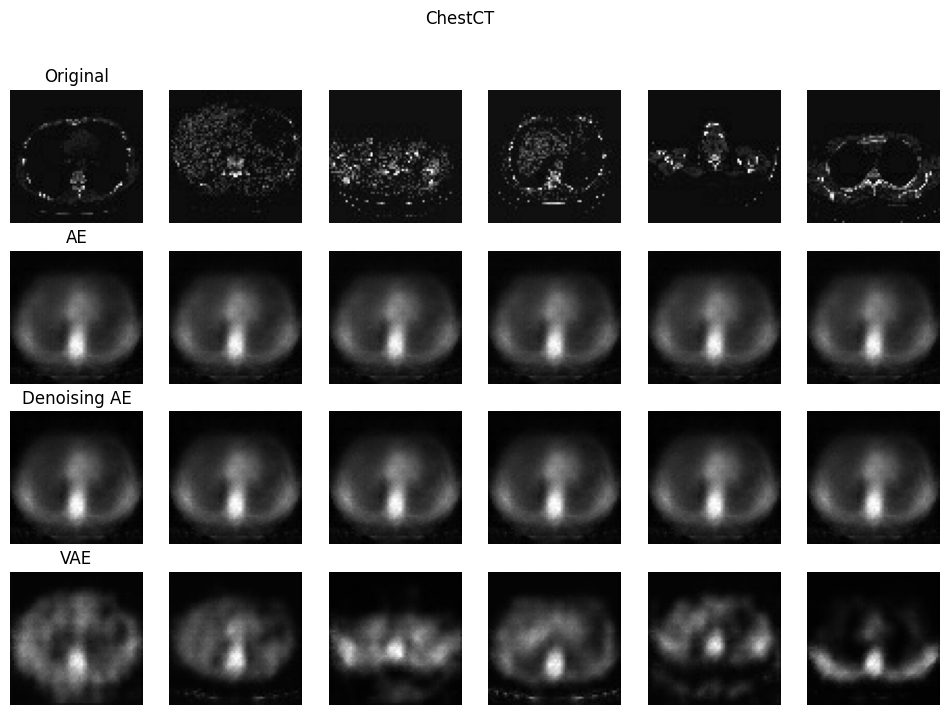

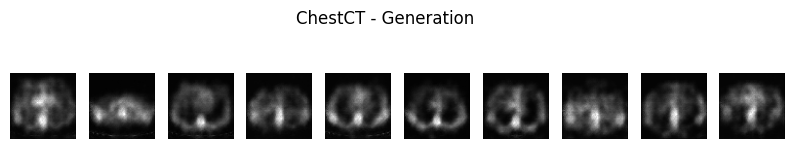

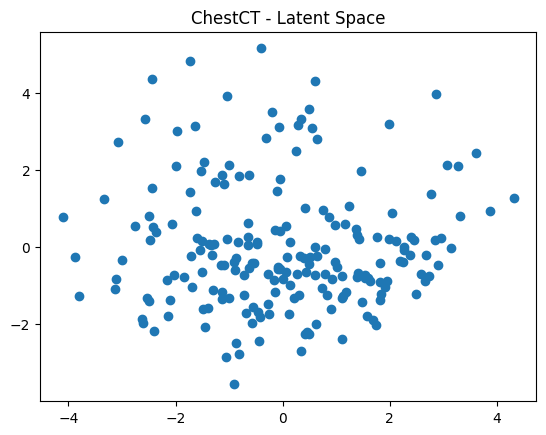

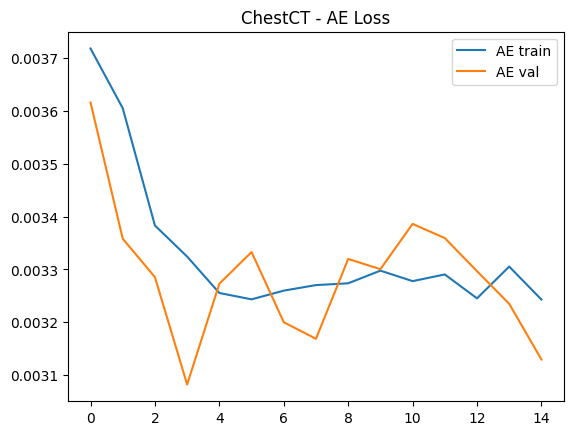

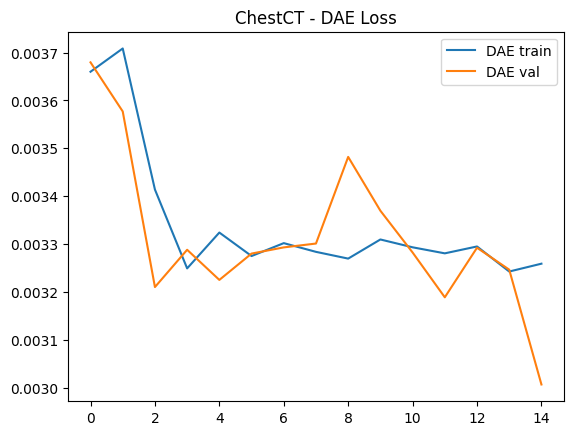

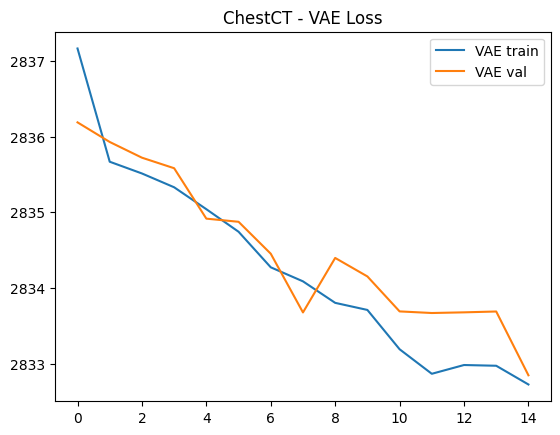

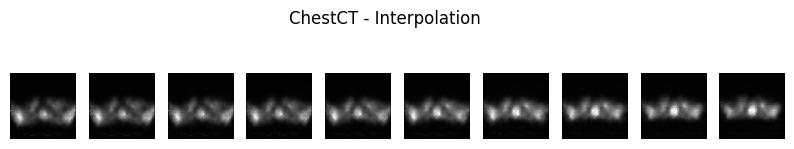

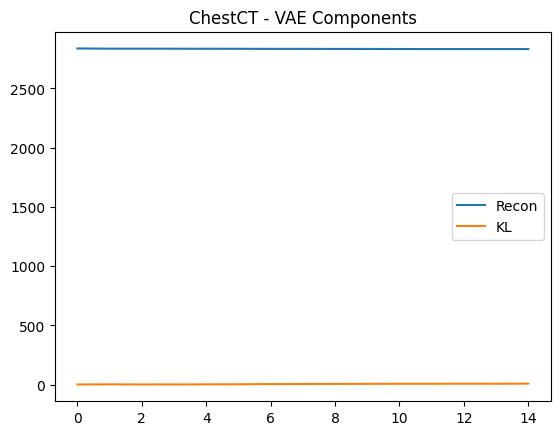

In [18]:
class_name = "ChestCT"

data = saved_models[class_name]

ae = data["ae"]
dae = data["dae"]
vae = data["vae"]
val_ds = data["val_ds"]
train_vae = data["train_vae"]
ae_hist = data["ae_hist"]
dae_hist = data["dae_hist"]
vae_hist = data["vae_hist"]

# reconstruction
x_batch,_ = next(iter(val_ds))

ae_pred = ae.predict(x_batch[:6])
dae_pred = dae.predict(x_batch[:6])
vae_pred = vae.predict(x_batch[:6])

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(4,6,i+1)
    plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # AE
    plt.subplot(4,6,i+7)
    img = ae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("AE")

    # DAE
    plt.subplot(4,6,i+13)
    img = dae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Denoising AE")

    # VAE
    plt.subplot(4,6,i+19)
    img = vae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE")

plt.suptitle(class_name)
plt.show()


# generation
z = tf.random.normal((10, LATENT_DIM))
gen = vae.decoder(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle(f"{class_name} - Generation")
plt.show()


# latent space
z_all = []
for x,_ in val_ds.take(10):
    mu = vae.mu(vae.encoder(x))
    z_all.append(mu.numpy())

z_all = np.concatenate(z_all)
z_2d = PCA(2).fit_transform(z_all)

plt.scatter(z_2d[:,0], z_2d[:,1])
plt.title(f"{class_name} - Latent Space")
plt.show()


# loss
plt.plot(ae_hist.history['loss'], label='AE train')
plt.plot(ae_hist.history['val_loss'], label='AE val')
plt.legend()
plt.title(f"{class_name} - AE Loss")
plt.show()

plt.plot(dae_hist.history['loss'], label='DAE train')
plt.plot(dae_hist.history['val_loss'], label='DAE val')
plt.legend()
plt.title(f"{class_name} - DAE Loss")
plt.show()

plt.plot(vae_hist.history['loss'], label='VAE train')
plt.plot(vae_hist.history['val_loss'], label='VAE val')
plt.legend()
plt.title(f"{class_name} - VAE Loss")
plt.show()


# interpolation
x,_ = next(iter(val_ds))

mu1 = vae.mu(vae.encoder(x[:1]))
mu2 = vae.mu(vae.encoder(x[1:2]))

plt.figure(figsize=(10,2))
for i,a in enumerate(np.linspace(0,1,10)):
    z = (1-a)*mu1 + a*mu2
    img = vae.decoder(z)

    plt.subplot(1,10,i+1)
    plt.imshow(img[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"{class_name} - Interpolation")
plt.show()


# VAE loss components
plt.plot(vae_hist.history['recon_loss'], label='Recon')
plt.plot(vae_hist.history['kl_loss'], label='KL')
plt.legend()
plt.title(f"{class_name} - VAE Components")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


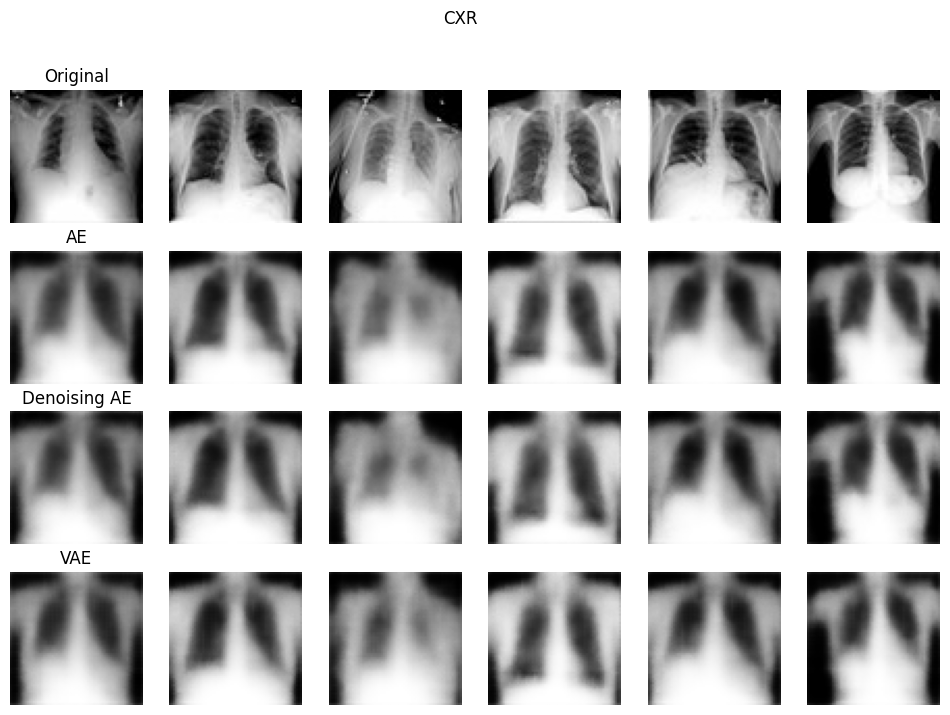

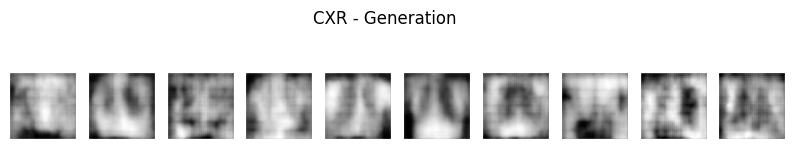

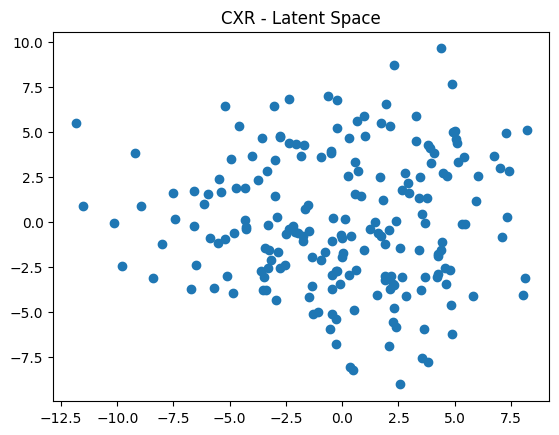

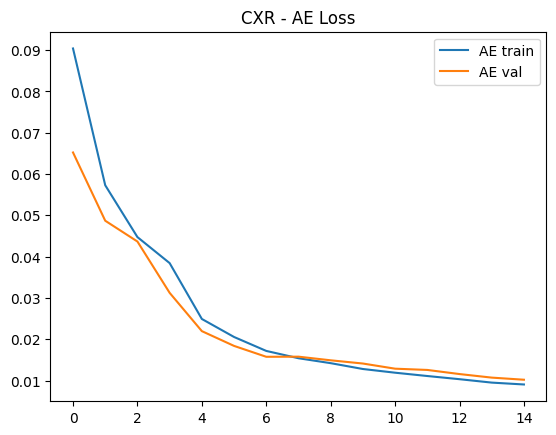

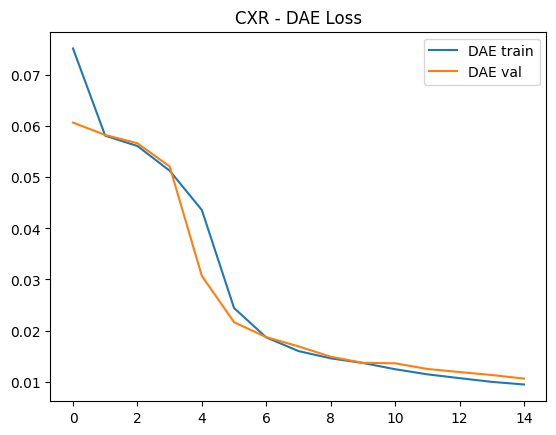

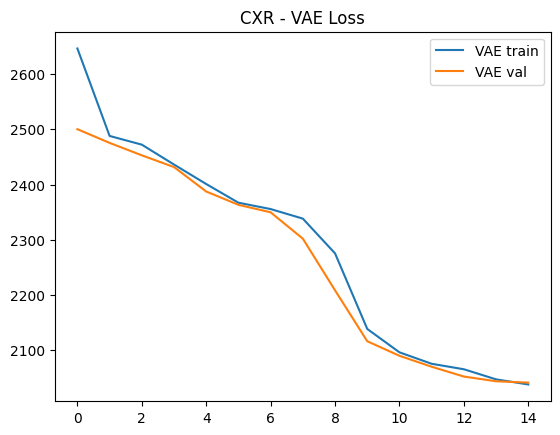

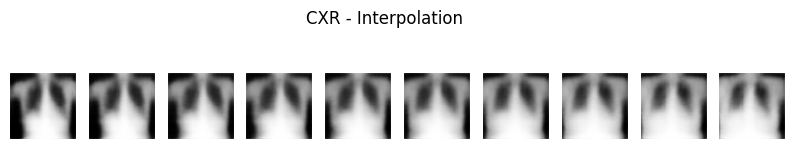

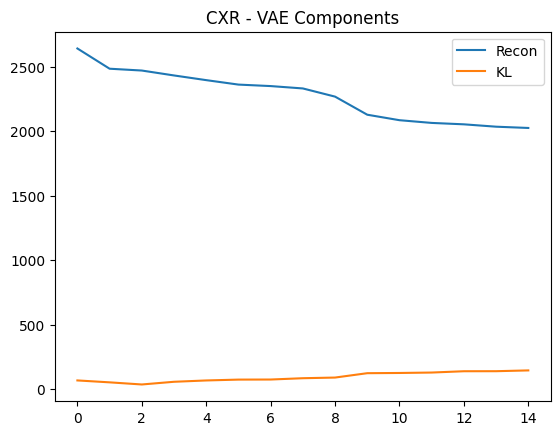

In [19]:
class_name = "CXR"

data = saved_models[class_name]

ae = data["ae"]
dae = data["dae"]
vae = data["vae"]
val_ds = data["val_ds"]
train_vae = data["train_vae"]
ae_hist = data["ae_hist"]
dae_hist = data["dae_hist"]
vae_hist = data["vae_hist"]

# reconstruction
x_batch,_ = next(iter(val_ds))

ae_pred = ae.predict(x_batch[:6])
dae_pred = dae.predict(x_batch[:6])
vae_pred = vae.predict(x_batch[:6])

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(4,6,i+1)
    plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # AE
    plt.subplot(4,6,i+7)
    img = ae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("AE")

    # DAE
    plt.subplot(4,6,i+13)
    img = dae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Denoising AE")

    # VAE
    plt.subplot(4,6,i+19)
    img = vae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE")

plt.suptitle(class_name)
plt.show()


# generation
z = tf.random.normal((10, LATENT_DIM))
gen = vae.decoder(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle(f"{class_name} - Generation")
plt.show()


# latent space
z_all = []
for x,_ in val_ds.take(10):
    mu = vae.mu(vae.encoder(x))
    z_all.append(mu.numpy())

z_all = np.concatenate(z_all)
z_2d = PCA(2).fit_transform(z_all)

plt.scatter(z_2d[:,0], z_2d[:,1])
plt.title(f"{class_name} - Latent Space")
plt.show()


# loss
plt.plot(ae_hist.history['loss'], label='AE train')
plt.plot(ae_hist.history['val_loss'], label='AE val')
plt.legend()
plt.title(f"{class_name} - AE Loss")
plt.show()

plt.plot(dae_hist.history['loss'], label='DAE train')
plt.plot(dae_hist.history['val_loss'], label='DAE val')
plt.legend()
plt.title(f"{class_name} - DAE Loss")
plt.show()

plt.plot(vae_hist.history['loss'], label='VAE train')
plt.plot(vae_hist.history['val_loss'], label='VAE val')
plt.legend()
plt.title(f"{class_name} - VAE Loss")
plt.show()


# interpolation
x,_ = next(iter(val_ds))

mu1 = vae.mu(vae.encoder(x[:1]))
mu2 = vae.mu(vae.encoder(x[1:2]))

plt.figure(figsize=(10,2))
for i,a in enumerate(np.linspace(0,1,10)):
    z = (1-a)*mu1 + a*mu2
    img = vae.decoder(z)

    plt.subplot(1,10,i+1)
    plt.imshow(img[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"{class_name} - Interpolation")
plt.show()


# VAE loss components
plt.plot(vae_hist.history['recon_loss'], label='Recon')
plt.plot(vae_hist.history['kl_loss'], label='KL')
plt.legend()
plt.title(f"{class_name} - VAE Components")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


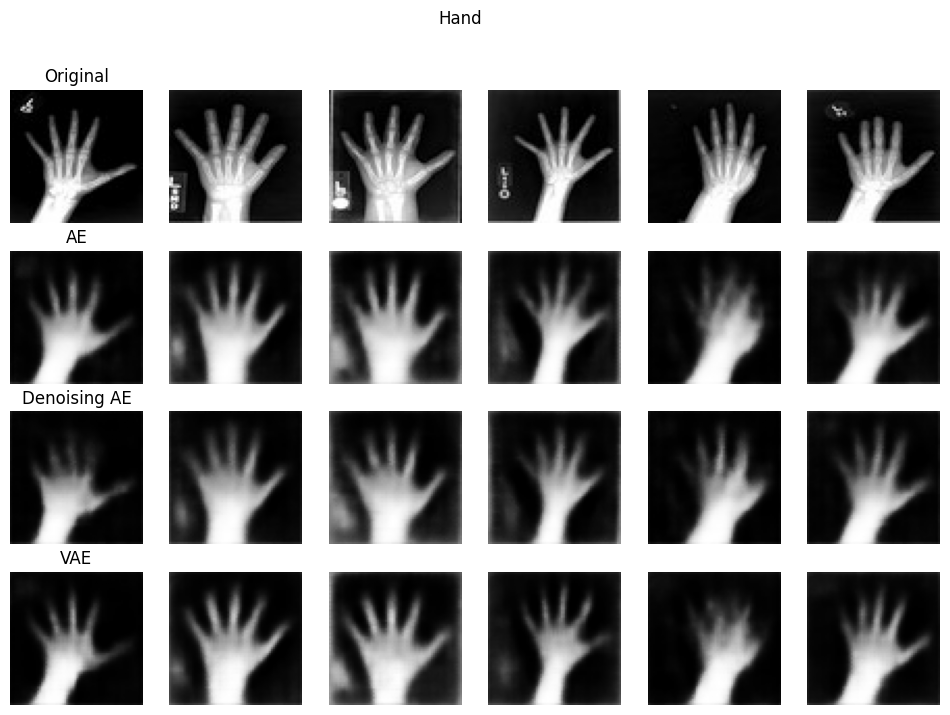

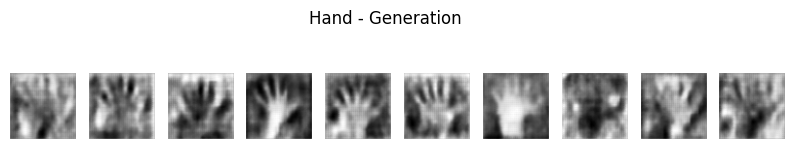

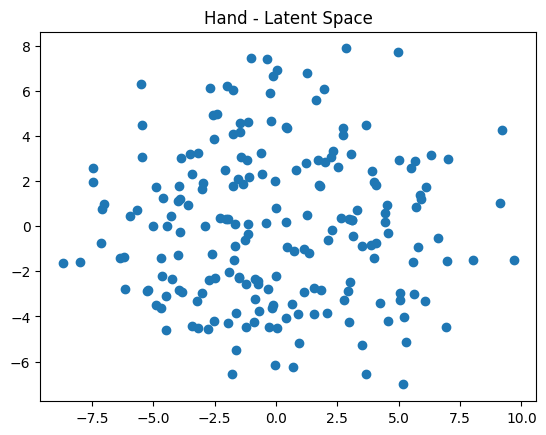

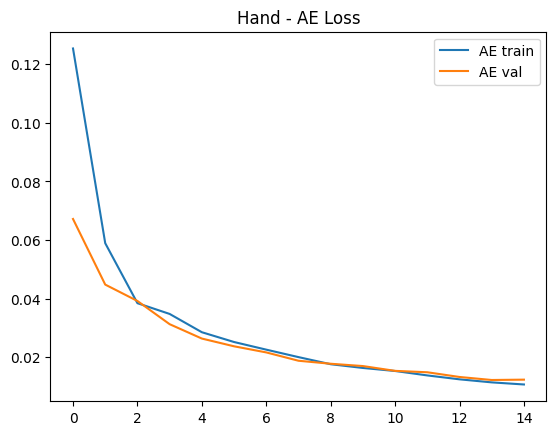

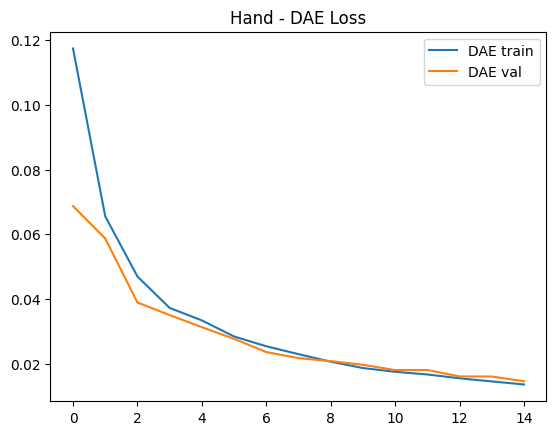

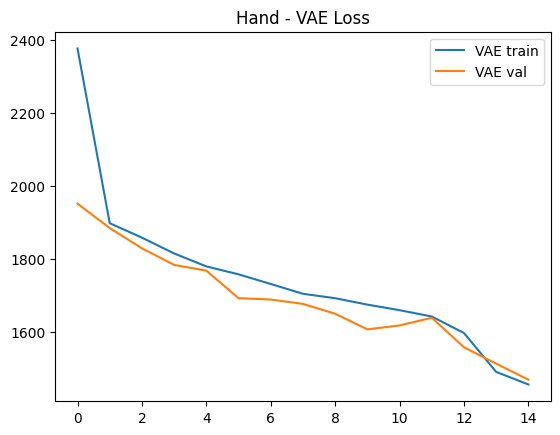

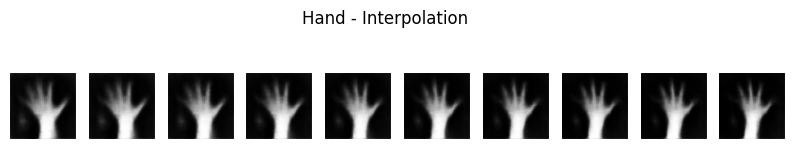

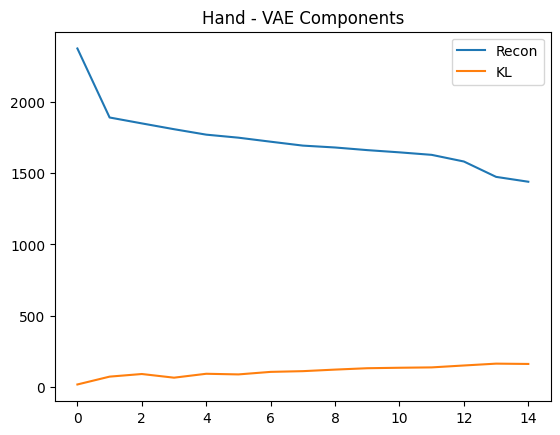

In [20]:
class_name = "Hand"

data = saved_models[class_name]

ae = data["ae"]
dae = data["dae"]
vae = data["vae"]
val_ds = data["val_ds"]
train_vae = data["train_vae"]
ae_hist = data["ae_hist"]
dae_hist = data["dae_hist"]
vae_hist = data["vae_hist"]

# reconstruction
x_batch,_ = next(iter(val_ds))

ae_pred = ae.predict(x_batch[:6])
dae_pred = dae.predict(x_batch[:6])
vae_pred = vae.predict(x_batch[:6])

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(4,6,i+1)
    plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # AE
    plt.subplot(4,6,i+7)
    img = ae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("AE")

    # DAE
    plt.subplot(4,6,i+13)
    img = dae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Denoising AE")

    # VAE
    plt.subplot(4,6,i+19)
    img = vae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE")

plt.suptitle(class_name)
plt.show()


# generation
z = tf.random.normal((10, LATENT_DIM))
gen = vae.decoder(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle(f"{class_name} - Generation")
plt.show()


# latent space
z_all = []
for x,_ in val_ds.take(10):
    mu = vae.mu(vae.encoder(x))
    z_all.append(mu.numpy())

z_all = np.concatenate(z_all)
z_2d = PCA(2).fit_transform(z_all)

plt.scatter(z_2d[:,0], z_2d[:,1])
plt.title(f"{class_name} - Latent Space")
plt.show()


# loss
plt.plot(ae_hist.history['loss'], label='AE train')
plt.plot(ae_hist.history['val_loss'], label='AE val')
plt.legend()
plt.title(f"{class_name} - AE Loss")
plt.show()

plt.plot(dae_hist.history['loss'], label='DAE train')
plt.plot(dae_hist.history['val_loss'], label='DAE val')
plt.legend()
plt.title(f"{class_name} - DAE Loss")
plt.show()

plt.plot(vae_hist.history['loss'], label='VAE train')
plt.plot(vae_hist.history['val_loss'], label='VAE val')
plt.legend()
plt.title(f"{class_name} - VAE Loss")
plt.show()


# interpolation
x,_ = next(iter(val_ds))

mu1 = vae.mu(vae.encoder(x[:1]))
mu2 = vae.mu(vae.encoder(x[1:2]))

plt.figure(figsize=(10,2))
for i,a in enumerate(np.linspace(0,1,10)):
    z = (1-a)*mu1 + a*mu2
    img = vae.decoder(z)

    plt.subplot(1,10,i+1)
    plt.imshow(img[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"{class_name} - Interpolation")
plt.show()


# VAE loss components
plt.plot(vae_hist.history['recon_loss'], label='Recon')
plt.plot(vae_hist.history['kl_loss'], label='KL')
plt.legend()
plt.title(f"{class_name} - VAE Components")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


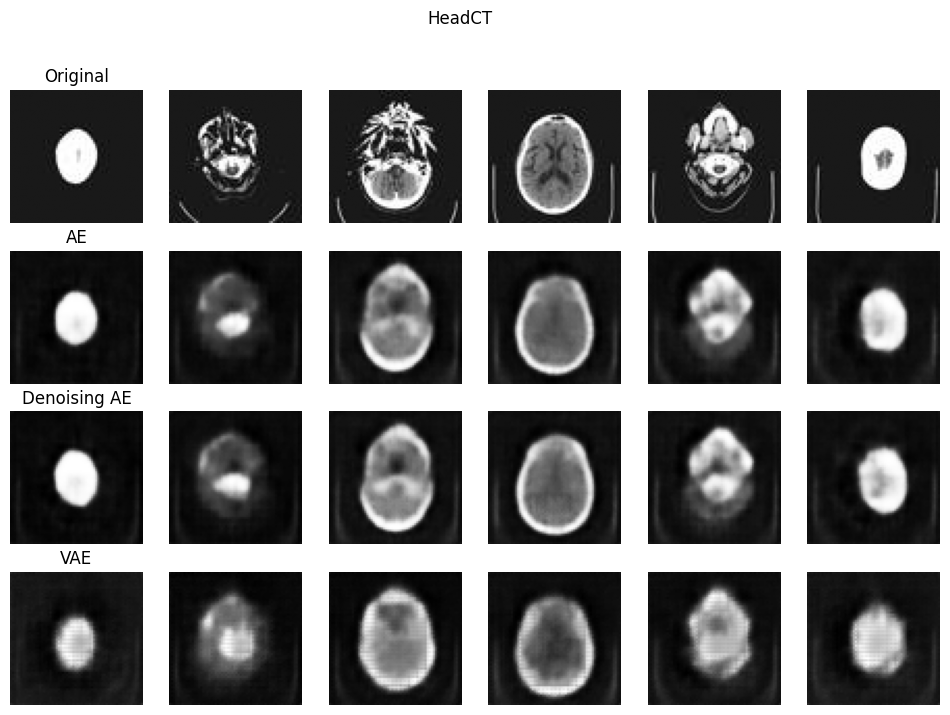

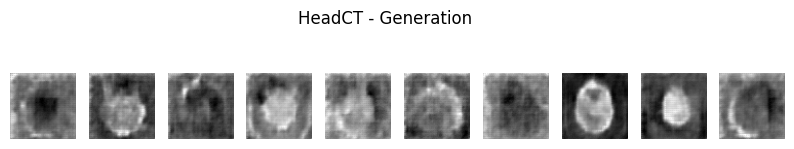

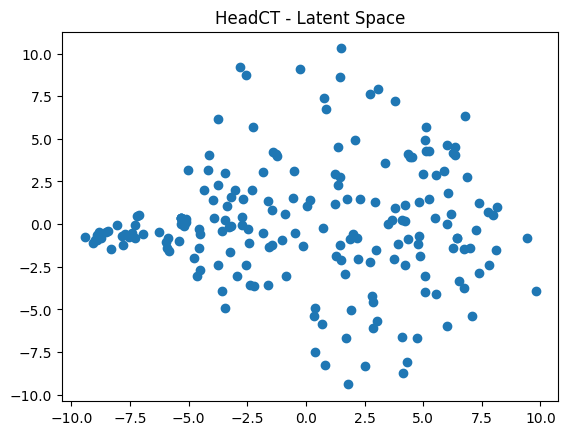

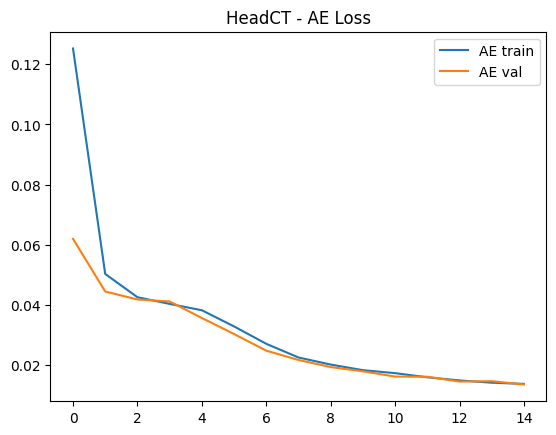

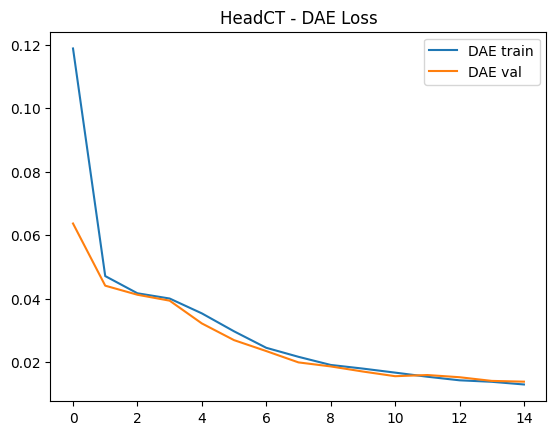

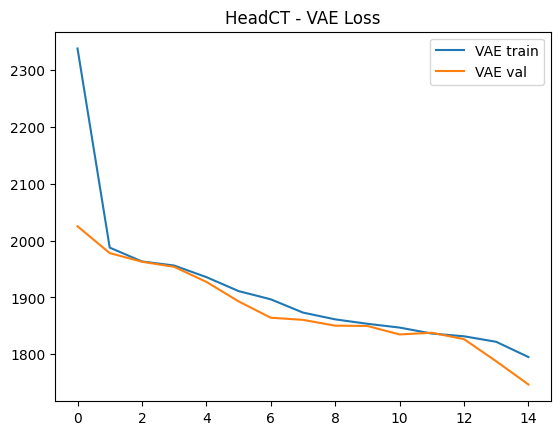

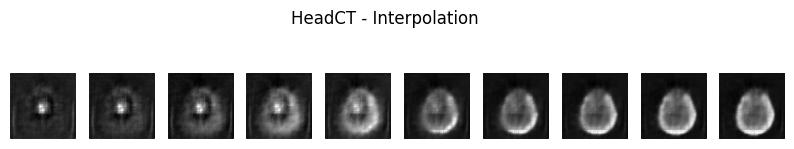

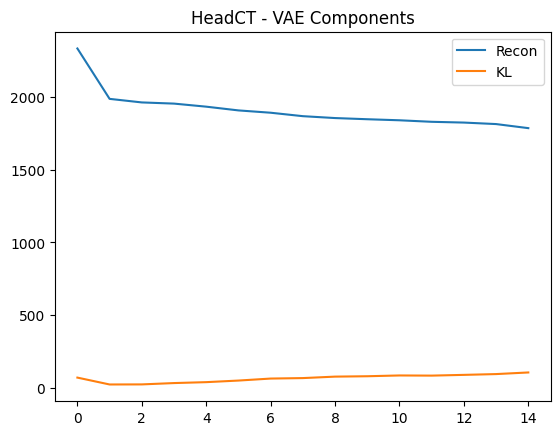

In [21]:
class_name = "HeadCT"

data = saved_models[class_name]

ae = data["ae"]
dae = data["dae"]
vae = data["vae"]
val_ds = data["val_ds"]
train_vae = data["train_vae"]
ae_hist = data["ae_hist"]
dae_hist = data["dae_hist"]
vae_hist = data["vae_hist"]

# reconstruction
x_batch,_ = next(iter(val_ds))

ae_pred = ae.predict(x_batch[:6])
dae_pred = dae.predict(x_batch[:6])
vae_pred = vae.predict(x_batch[:6])

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(4,6,i+1)
    plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # AE
    plt.subplot(4,6,i+7)
    img = ae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("AE")

    # DAE
    plt.subplot(4,6,i+13)
    img = dae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Denoising AE")

    # VAE
    plt.subplot(4,6,i+19)
    img = vae_pred[i].squeeze()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE")

plt.suptitle(class_name)
plt.show()


# generation
z = tf.random.normal((10, LATENT_DIM))
gen = vae.decoder(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle(f"{class_name} - Generation")
plt.show()


# latent space
z_all = []
for x,_ in val_ds.take(10):
    mu = vae.mu(vae.encoder(x))
    z_all.append(mu.numpy())

z_all = np.concatenate(z_all)
z_2d = PCA(2).fit_transform(z_all)

plt.scatter(z_2d[:,0], z_2d[:,1])
plt.title(f"{class_name} - Latent Space")
plt.show()


# loss
plt.plot(ae_hist.history['loss'], label='AE train')
plt.plot(ae_hist.history['val_loss'], label='AE val')
plt.legend()
plt.title(f"{class_name} - AE Loss")
plt.show()

plt.plot(dae_hist.history['loss'], label='DAE train')
plt.plot(dae_hist.history['val_loss'], label='DAE val')
plt.legend()
plt.title(f"{class_name} - DAE Loss")
plt.show()

plt.plot(vae_hist.history['loss'], label='VAE train')
plt.plot(vae_hist.history['val_loss'], label='VAE val')
plt.legend()
plt.title(f"{class_name} - VAE Loss")
plt.show()


# interpolation
x,_ = next(iter(val_ds))

mu1 = vae.mu(vae.encoder(x[:1]))
mu2 = vae.mu(vae.encoder(x[1:2]))

plt.figure(figsize=(10,2))
for i,a in enumerate(np.linspace(0,1,10)):
    z = (1-a)*mu1 + a*mu2
    img = vae.decoder(z)

    plt.subplot(1,10,i+1)
    plt.imshow(img[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"{class_name} - Interpolation")
plt.show()


# VAE loss components
plt.plot(vae_hist.history['recon_loss'], label='Recon')
plt.plot(vae_hist.history['kl_loss'], label='KL')
plt.legend()
plt.title(f"{class_name} - VAE Components")
plt.show()